# `comp_*` Context Analysis

This notebook does:

1. Inventory analysis for every `comp_*` file.
2. Plots every `comp_*` file in the notebook.
3. Builds the merged contemporary layer for `renove → contemporain`.
4. Runs pairwise before/after analysis for all available comparisons.
5. Saves outputs if `SAVE_OUTPUTS = True`.

Output structure when saving is enabled:

```text
stat_analysis/output/comp_analysis_refactored/<comparison_key>/
├── raw/
│   ├── tables/
│   └── figures/
└── shared_intersection/
    ├── tables/
    └── figures/
```

In [1]:
from pathlib import Path
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

In [3]:
REPO_ROOT = Path("../..")

MAPS_DIR = REPO_ROOT / "maps"
if not MAPS_DIR.exists():
    MAPS_DIR = Path("../maps")

OUTPUT_ROOT = REPO_ROOT / "stat_analysis" / "output" / "comp_analysis_refactored"
if not OUTPUT_ROOT.parent.exists():
    OUTPUT_ROOT = Path("../stat_analysis/output/comp_analysis_refactored")

TARGET_EPSG = 2056
LINE_BUFFER_M = 5

SAVE_OUTPUTS = True

CUSTOM_COLORS = {
    "built": "#FF9F0A",
    "non-built": "#34C759",
    "road_network": "#8E8E93",
    "water": "#007AFF",
    "unclassified": "#F2F2F7",
}

GROUP_COLORS = {
    "became road": "#8E8E93",
    "became built": "#FF9F0A",
    "became non-built": "#34C759",
    "became water": "#007AFF",
    "other": "#D1D1D6",
}

MAP_ORDER = {
    "melotte": 1721,
    "berney": 1831,
    "renove": 1888,
    "1937": 1937,
    "1959": 1959,
    "contemporain": 2021,
}

MAP_LABELS = {
    "melotte": "Melotte (1721)",
    "berney": "Berney (1831)",
    "renove": "Rénové (1888)",
    "1937": "1937",
    "1959": "1959",
    "contemporain": "Contemporary (2021)",
}

In [4]:
print("MAPS_DIR:", MAPS_DIR, MAPS_DIR.exists())
print("OUTPUT_ROOT:", OUTPUT_ROOT)
print("SAVE_OUTPUTS:", SAVE_OUTPUTS)

MAPS_DIR: ../../maps True
OUTPUT_ROOT: ../../stat_analysis/output/comp_analysis_refactored
SAVE_OUTPUTS: True


In [16]:
def sort_key_for_map(map_key):
    if map_key in MAP_ORDER:
        return MAP_ORDER[map_key]
    if str(map_key).isdigit():
        return int(map_key)
    return 9999


def label_for_map(map_key):
    return MAP_LABELS.get(map_key, str(map_key))


def parse_comp_filename(path):
    parts = path.stem.split("_")
    return {
        "file": path.name,
        "path": path,
        "comparison_key": parts[1] if len(parts) > 1 else None,
        "shown_on_map": parts[2] if len(parts) > 2 else None,
        "layer_name": "_".join(parts[3:]) if len(parts) > 3 else "context",
    }


def discover_comp_files():
    return pd.DataFrame([parse_comp_filename(p) for p in sorted(MAPS_DIR.glob("comp_*.gpkg"))])


def load_gpkg(path):
    gdf = gpd.read_file(path)
    if gdf.crs is None:
        raise ValueError(f"Missing CRS: {path}")
    gdf = gdf.to_crs(epsg=TARGET_EPSG)
    gdf = gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty].copy()
    gdf["geometry"] = gdf.geometry.make_valid()
    return gdf


def load_classified_comp(path):
    CLASS_NORMALIZATION = {
    "buildings": "built",
    "built": "built",
    "road network": "road_network",
    "road_network": "road_network",
    "undecided": "non-built",
    "non-built": "non-built",
    "water": "water",
    }

    gdf = load_gpkg(path)
    if "class" not in gdf.columns:
        gdf["class"] = "unclassified"

    gdf["class"] = (
        gdf["class"]
        .fillna("unclassified")
        .astype(str)
        .str.lower()
        .str.strip()
        .map(CLASS_NORMALIZATION)
        .fillna("unclassified")
    )
    
    gdf["area_m2"] = gdf.geometry.area
    gdf["area_ha"] = gdf["area_m2"] / 10_000
    return gdf


def summarize_categories(gdf, label):
    return (
        gdf.groupby("class", dropna=False)
        .agg(
            feature_count=("geometry", "count"),
            total_area_m2=("area_m2", "sum"),
            total_area_ha=("area_ha", "sum"),
        )
        .reset_index()
        .assign(map=label)
        .sort_values("total_area_ha", ascending=False)
    )


def is_save_table(df, path):
    if SAVE_OUTPUTS:
        path.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(path, index=False)
        print("Saved:", path)


def is_savefig(path):
    if SAVE_OUTPUTS:
        path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(path, dpi=200, bbox_inches="tight")
        print("Saved:", path)

## 1. Inventory analysis for every `comp_*` file

In [17]:
comp_index = discover_comp_files()
display(comp_index)

,file,path,comparison_key,shown_on_map,layer_name
0,comp_berneyrenove_berney.gpkg,../../maps/comp_berneyrenove_berney.gpkg,berneyrenove,berney,context
1,comp_berneyrenove_renove.gpkg,../../maps/comp_berneyrenove_renove.gpkg,berneyrenove,renove,context
2,comp_melotteberney_berney.gpkg,../../maps/comp_melotteberney_berney.gpkg,melotteberney,berney,context
3,comp_melotteberney_melotte.gpkg,../../maps/comp_melotteberney_melotte.gpkg,melotteberney,melotte,context
4,comp_renovecontemporain_contemporain_buildings.gpkg,../../maps/comp_renovecontemporain_contemporain_buildings.gpkg,renovecontemporain,contemporain,buildings
5,comp_renovecontemporain_contemporain_landuse.gpkg,../../maps/comp_renovecontemporain_contemporain_landuse.gpkg,renovecontemporain,contemporain,landuse
6,comp_renovecontemporain_contemporain_naturals.gpkg,../../maps/comp_renovecontemporain_contemporain_naturals.gpkg,renovecontemporain,contemporain,naturals
7,comp_renovecontemporain_contemporain_railways.gpkg,../../maps/comp_renovecontemporain_contemporain_railways.gpkg,renovecontemporain,contemporain,railways
8,comp_renovecontemporain_contemporain_roads.gpkg,../../maps/comp_renovecontemporain_contemporain_roads.gpkg,renovecontemporain,contemporain,roads
9,comp_renovecontemporain_renove.gpkg,../../maps/comp_renovecontemporain_renove.gpkg,renovecontemporain,renove,context


In [18]:
inventory_rows = []

for _, row in comp_index.iterrows():
    gdf = gpd.read_file(row["path"])
    inventory_rows.append({
        "file": row["file"],
        "comparison_key": row["comparison_key"],
        "shown_on_map": row["shown_on_map"],
        "layer_name": row["layer_name"],
        "rows": len(gdf),
        "crs": str(gdf.crs),
        "geometry_types": ", ".join(gdf.geom_type.value_counts().index.astype(str)),
        "columns": ", ".join(gdf.columns.astype(str)),
    })

inventory_df = pd.DataFrame(inventory_rows)
display(inventory_df)

,file,comparison_key,shown_on_map,layer_name,rows,crs,geometry_types,columns
0,comp_berneyrenove_berney.gpkg,berneyrenove,berney,context,325,EPSG:2056,MultiPolygon,"class, layer, path, identifier, page, number, subclass, use, own_type, own_desc, own_share, own_col_ty, own_col_de, own_surnam, own_name, own_compl, area, geometry"
1,comp_berneyrenove_renove.gpkg,berneyrenove,renove,context,647,EPSG:2056,MultiPolygon,"class, layer, geometry"
2,comp_melotteberney_berney.gpkg,melotteberney,berney,context,450,EPSG:2056,MultiPolygon,"class, layer, path, identifier, page, number, subclass, use, own_type, own_desc, own_share, own_col_ty, own_col_de, own_surnam, own_name, own_compl, area, geometry"
3,comp_melotteberney_melotte.gpkg,melotteberney,melotte,context,354,EPSG:2056,MultiPolygon,"class, layer, path, geometry"
4,comp_renovecontemporain_contemporain_buildings.gpkg,renovecontemporain,contemporain,buildings,255,EPSG:4326,MultiPolygon,"osm_id, name, type, geometry"
5,comp_renovecontemporain_contemporain_landuse.gpkg,renovecontemporain,contemporain,landuse,23,EPSG:4326,MultiPolygon,"osm_id, name, type, geometry"
6,comp_renovecontemporain_contemporain_naturals.gpkg,renovecontemporain,contemporain,naturals,8,EPSG:4326,MultiPolygon,"osm_id, name, type, geometry"
7,comp_renovecontemporain_contemporain_railways.gpkg,renovecontemporain,contemporain,railways,47,EPSG:4326,MultiLineString,"osm_id, name, type, geometry"
8,comp_renovecontemporain_contemporain_roads.gpkg,renovecontemporain,contemporain,roads,358,EPSG:4326,MultiLineString,"osm_id, name, ref, type, oneway, bridge, maxspeed, geometry"
9,comp_renovecontemporain_renove.gpkg,renovecontemporain,renove,context,2408,EPSG:2056,MultiPolygon,"class, layer, geometry"


## 2. Plot every simple `comp_*` context file in the notebook

In [19]:
def plot_single_comp_file(path):
    gdf = load_classified_comp(path)
    gdf["color"] = gdf["class"].map(CUSTOM_COLORS).fillna(CUSTOM_COLORS["unclassified"])

    fig, ax = plt.subplots(figsize=(7, 7))
    gdf.plot(ax=ax, color=gdf["color"], alpha=0.85, edgecolor="white", linewidth=0.2)

    ax.set_title(path.name, fontsize=12, fontweight="bold")
    ax.set_axis_off()
    ax.set_aspect("equal")

    legend_items = [
        mpatches.Patch(color=color, label=label)
        for label, color in CUSTOM_COLORS.items()
        if label in gdf["class"].unique()
    ]
    ax.legend(handles=legend_items, title="Class", loc="best", frameon=False)

    plt.tight_layout()
    plt.show()

    summary = summarize_categories(gdf, path.stem)
    display(summary)
    return gdf, summary


comp_berneyrenove_berney.gpkg


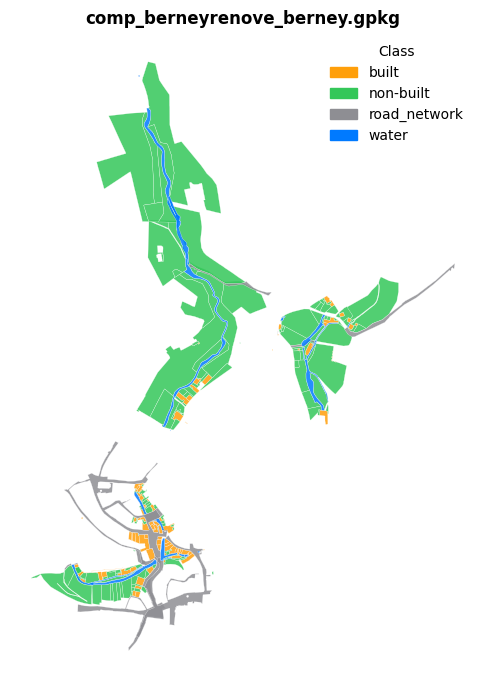

,class,feature_count,total_area_m2,total_area_ha,map
1,non-built,162,142453.052924,14.245305,comp_berneyrenove_berney
2,road_network,17,23221.409378,2.322141,comp_berneyrenove_berney
3,water,28,10526.421176,1.052642,comp_berneyrenove_berney
0,built,118,10152.792741,1.015279,comp_berneyrenove_berney



comp_berneyrenove_renove.gpkg


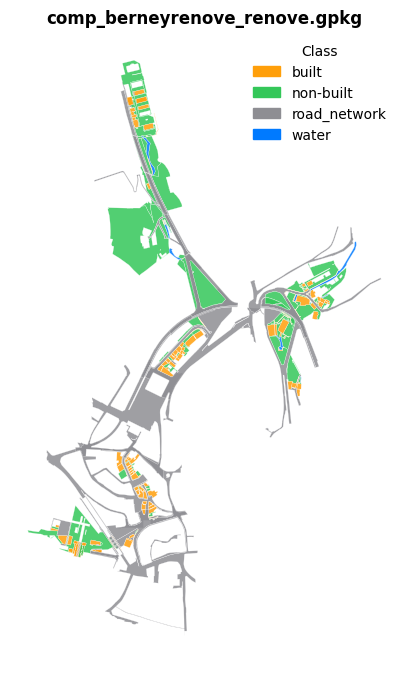

,class,feature_count,total_area_m2,total_area_ha,map
2,road_network,121,98131.597891,9.813160,comp_berneyrenove_renove
1,non-built,173,59441.988334,5.944199,comp_berneyrenove_renove
0,built,330,15246.130591,1.524613,comp_berneyrenove_renove
3,water,23,1998.655915,0.199866,comp_berneyrenove_renove



comp_melotteberney_berney.gpkg


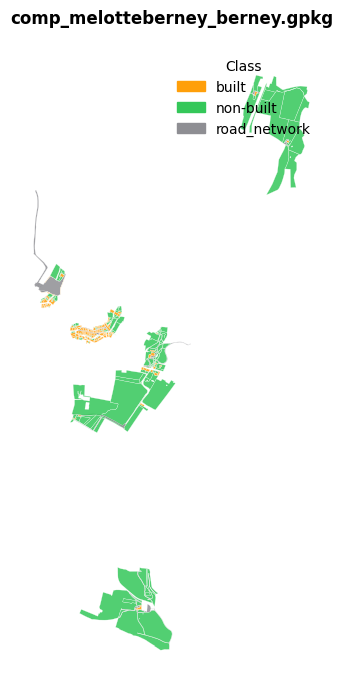

,class,feature_count,total_area_m2,total_area_ha,map
1,non-built,227,319774.217409,31.977422,comp_melotteberney_berney
2,road_network,35,24667.539417,2.466754,comp_melotteberney_berney
0,built,188,18853.196747,1.885320,comp_melotteberney_berney



comp_melotteberney_melotte.gpkg


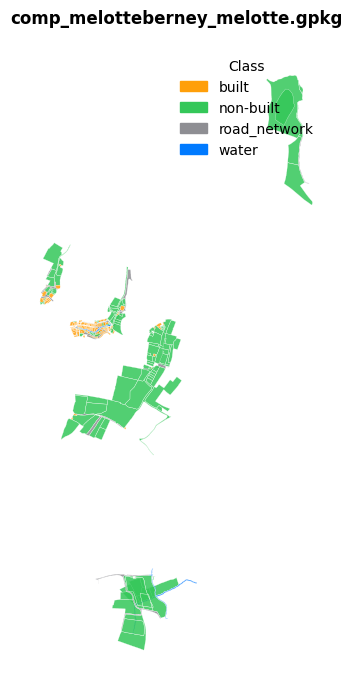

,class,feature_count,total_area_m2,total_area_ha,map
1,non-built,169,312163.992281,31.216399,comp_melotteberney_melotte
2,road_network,43,16251.816721,1.625182,comp_melotteberney_melotte
0,built,130,15123.063995,1.512306,comp_melotteberney_melotte
3,water,12,4413.496342,0.441350,comp_melotteberney_melotte



comp_renovecontemporain_renove.gpkg


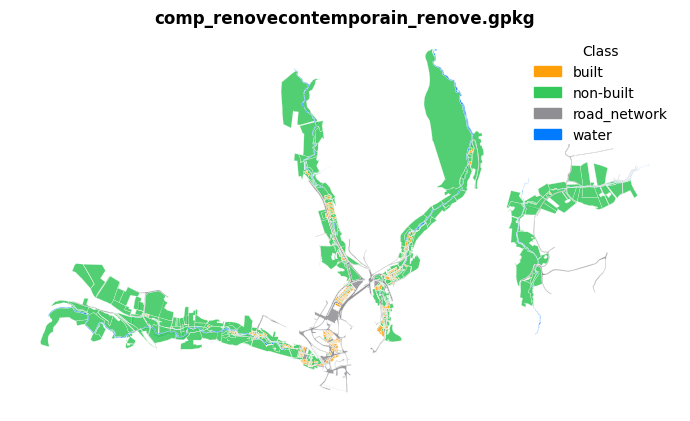

,class,feature_count,total_area_m2,total_area_ha,map
1,non-built,725,1.113192e+06,111.319232,comp_renovecontemporain_renove
2,road_network,308,1.638356e+05,16.383556,comp_renovecontemporain_renove
3,water,198,5.982706e+04,5.982706,comp_renovecontemporain_renove
0,built,1177,4.857377e+04,4.857377,comp_renovecontemporain_renove


In [20]:
simple_context_files = comp_index[comp_index["layer_name"].eq("context")]["path"].tolist()

for path in simple_context_files:
    print("\n" + "=" * 80)
    print(path.name)
    plot_single_comp_file(path)

## 3. Contemporary split layers: inventory, category review, and merge

In [21]:
def classify_contemporary(source_layer, typ):
    typ = str(typ).lower()

    if source_layer == "buildings":
        return "built"
    if source_layer in ["roads", "railways"]:
        return "road_network"
    if source_layer == "naturals":
        if typ == "water":
            return "water"
        return "non-built"
    if source_layer == "landuse":
        return "non-built"

    return "unclassified"


def load_contemporary_merged():
    contemp_files = sorted(MAPS_DIR.glob("comp_renovecontemporain_contemporain_*.gpkg"))
    review_rows = []
    merged_layers = []

    for path in contemp_files:
        source_layer = path.stem.replace("comp_renovecontemporain_contemporain_", "")
        gdf = load_gpkg(path)

        if gdf.geom_type.isin(["LineString", "MultiLineString"]).any():
            gdf["geometry"] = gdf.geometry.buffer(LINE_BUFFER_M)

        if "type" not in gdf.columns:
            gdf["type"] = None

        gdf["source_layer"] = source_layer
        gdf["type_clean"] = gdf["type"].fillna("no subtype").astype(str)
        gdf["class"] = gdf.apply(
            lambda row: classify_contemporary(row["source_layer"], row["type_clean"]),
            axis=1,
        )
        gdf["area_m2"] = gdf.geometry.area
        gdf["area_ha"] = gdf["area_m2"] / 10_000

        review = (
            gdf.groupby(["source_layer", "type_clean", "class"], as_index=False)
            .agg(count=("geometry", "count"), area_ha=("area_ha", "sum"))
            .sort_values(["source_layer", "area_ha"], ascending=[True, False])
        )
        review_rows.append(review)
        merged_layers.append(gdf)

    mapping_review = pd.concat(review_rows, ignore_index=True) if review_rows else pd.DataFrame()

    if merged_layers:
        merged = gpd.GeoDataFrame(
            pd.concat(merged_layers, ignore_index=True),
            geometry="geometry",
            crs=f"EPSG:{TARGET_EPSG}",
        )
    else:
        merged = gpd.GeoDataFrame(columns=["class", "geometry"], geometry="geometry", crs=f"EPSG:{TARGET_EPSG}")

    return merged, mapping_review


contemporain_merged, contemporain_mapping_review = load_contemporary_merged()

print("Mapping review:")
display(contemporain_mapping_review)

print("Merged contemporary summary:")
display(
    contemporain_merged.groupby(["source_layer", "class"], as_index=False)
    .agg(count=("geometry", "count"), area_ha=("area_ha", "sum"))
    .sort_values("area_ha", ascending=False)
)

Mapping review:


,source_layer,type_clean,class,count,area_ha
0,buildings,no subtype,built,213,14.183439
1,buildings,apartments,built,12,0.621950
2,buildings,parking,built,2,0.425146
3,buildings,school,built,3,0.345175
4,buildings,office,built,1,0.298807
5,buildings,industrial,built,3,0.206375
6,buildings,fire_station,built,1,0.206136
7,buildings,public,built,1,0.202501
8,buildings,cinema,built,1,0.191063
9,buildings,theatre,built,1,0.185019


Merged contemporary summary:


,source_layer,class,count,area_ha
1,landuse,non-built,23,58.308473
5,roads,road_network,358,34.178106
0,buildings,built,255,17.388856
4,railways,road_network,47,14.849775
2,naturals,non-built,6,2.271875
3,naturals,water,2,0.015253


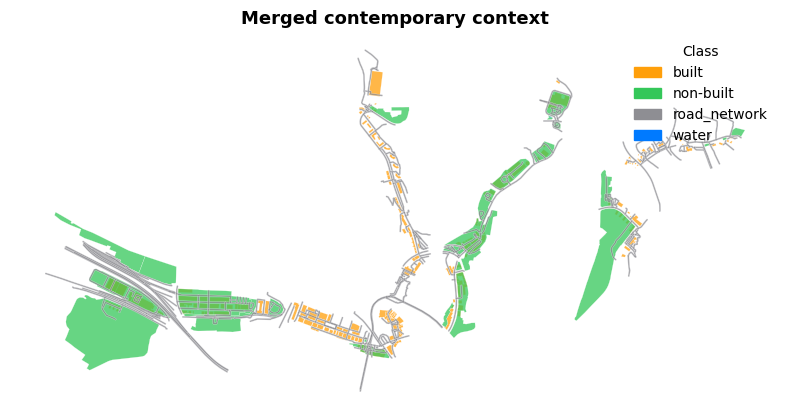

In [22]:
if not contemporain_merged.empty:
    tmp = contemporain_merged.copy()
    tmp["color"] = tmp["class"].map(CUSTOM_COLORS).fillna(CUSTOM_COLORS["unclassified"])

    fig, ax = plt.subplots(figsize=(8, 8))
    tmp.plot(ax=ax, color=tmp["color"], alpha=0.75, edgecolor="white", linewidth=0.2)

    ax.set_title("Merged contemporary context", fontsize=13, fontweight="bold")
    ax.set_axis_off()
    ax.set_aspect("equal")

    legend_items = [
        mpatches.Patch(color=color, label=label)
        for label, color in CUSTOM_COLORS.items()
        if label in tmp["class"].unique()
    ]
    ax.legend(handles=legend_items, title="Class", loc="best", frameon=False)

    plt.tight_layout()
    plt.show()

## 4. Pairwise analysis helpers

In [23]:
def get_shared_bounds(*gdfs):
    bounds = pd.concat([gdf.geometry.bounds for gdf in gdfs if not gdf.empty])
    return bounds["minx"].min(), bounds["miny"].min(), bounds["maxx"].max(), bounds["maxy"].max()


def style_map_axis(ax, bounds):
    xmin, ymin, xmax, ymax = bounds
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal", adjustable="box")
    ax.set_axis_off()


def add_class_legend(fig, y=-0.02):
    legend_items = [
        mpatches.Patch(color=color, label=label)
        for label, color in CUSTOM_COLORS.items()
        if label != "unclassified"
    ]
    fig.legend(
        handles=legend_items,
        title="Class",
        loc="lower center",
        ncol=4,
        frameon=False,
        bbox_to_anchor=(0.5, y),
    )


def plot_before_after_maps(before, after, before_label, after_label, title_prefix, out_path=None):
    before = before.copy()
    after = after.copy()
    bounds = get_shared_bounds(before, after)

    before["color"] = before["class"].map(CUSTOM_COLORS).fillna(CUSTOM_COLORS["unclassified"])
    after["color"] = after["class"].map(CUSTOM_COLORS).fillna(CUSTOM_COLORS["unclassified"])

    fig, axes = plt.subplots(1, 2, figsize=(15, 7))
    before.plot(ax=axes[0], color=before["color"], alpha=0.85, edgecolor="white", linewidth=0.25)
    after.plot(ax=axes[1], color=after["color"], alpha=0.85, edgecolor="white", linewidth=0.25)

    axes[0].set_title(f"{title_prefix}: {before_label}", fontsize=13, fontweight="bold")
    axes[1].set_title(f"{title_prefix}: {after_label}", fontsize=13, fontweight="bold")

    for ax in axes:
        style_map_axis(ax, bounds)

    add_class_legend(fig)
    plt.tight_layout(rect=[0, 0.08, 1, 1])

    if out_path is not None:
        is_savefig(out_path)

    plt.show()


def plot_category_graph(summary_df, title, out_path=None):
    categories = ["built", "non-built", "road_network", "water"]
    maps = list(summary_df["map"].unique())

    if len(maps) != 2:
        print("Skipping category graph; expected 2 maps:", maps)
        return

    left = summary_df[summary_df["map"] == maps[0]].set_index("class").reindex(categories).fillna(0).reset_index()
    right = summary_df[summary_df["map"] == maps[1]].set_index("class").reindex(categories).fillna(0).reset_index()

    max_area = max(left["total_area_ha"].max(), right["total_area_ha"].max()) * 1.15
    if max_area == 0:
        max_area = 1

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

    for ax, df, subtitle in [(axes[0], left, maps[0]), (axes[1], right, maps[1])]:
        colors = [CUSTOM_COLORS.get(c, "#D1D1D6") for c in df["class"]]
        ax.barh(df["class"], df["total_area_ha"], color=colors, edgecolor="white", linewidth=1.2)
        ax.set_title(subtitle, fontsize=13, fontweight="bold")
        ax.set_xlabel("Area (ha)")
        ax.set_xlim(0, max_area)
        ax.grid(axis="x", linestyle="--", alpha=0.25)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(False)

        for i, value in enumerate(df["total_area_ha"]):
            ax.text(value + max_area * 0.015, i, f"{value:.2f}", va="center", fontsize=9)

    axes[0].set_ylabel("Class")
    fig.suptitle(title, fontsize=15, fontweight="bold")
    plt.tight_layout()

    if out_path is not None:
        is_savefig(out_path)

    plt.show()


def prepare_shared_area(before_gdf, after_gdf):
    before = before_gdf.to_crs(epsg=TARGET_EPSG).copy()
    after = after_gdf.to_crs(epsg=TARGET_EPSG).copy()

    shared_area = before.geometry.union_all().intersection(after.geometry.union_all())

    before_shared = gpd.clip(before, shared_area)
    after_shared = gpd.clip(after, shared_area)

    before_shared["area_m2"] = before_shared.geometry.area
    before_shared["area_ha"] = before_shared["area_m2"] / 10_000
    after_shared["area_m2"] = after_shared.geometry.area
    after_shared["area_ha"] = after_shared["area_m2"] / 10_000

    return before_shared, after_shared, shared_area


def compute_changed_areas(before_shared, after_shared):
    before = before_shared[["class", "geometry"]].rename(columns={"class": "class_before"})
    after = after_shared[["class", "geometry"]].rename(columns={"class": "class_after"})

    changed = gpd.overlay(before, after, how="intersection", keep_geom_type=False)
    changed = changed[changed.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
    changed = changed[changed["class_before"] != changed["class_after"]].copy()

    changed["area_m2"] = changed.geometry.area
    changed["area_ha"] = changed["area_m2"] / 10_000
    changed["change_type"] = changed["class_before"] + " → " + changed["class_after"]

    def simplify_change(row):
        if row["class_after"] == "road_network":
            return "became road"
        if row["class_after"] == "built":
            return "became built"
        if row["class_after"] == "non-built":
            return "became non-built"
        if row["class_after"] == "water":
            return "became water"
        return "other"

    changed["change_group"] = changed.apply(simplify_change, axis=1)
    changed["color"] = changed["change_group"].map(GROUP_COLORS).fillna("#D1D1D6")
    return changed


def plot_changed_only_map(changed, before_shared, after_shared, out_path=None):
    if changed.empty:
        print("No changed areas to plot.")
        return

    bounds = get_shared_bounds(before_shared, after_shared)
    fig, ax = plt.subplots(figsize=(12, 8))

    changed.plot(ax=ax, color=changed["color"], alpha=0.9, edgecolor="white", linewidth=0.25)
    ax.set_title("Only areas where category changed", fontsize=13, fontweight="bold")
    style_map_axis(ax, bounds)

    legend_items = [
        mpatches.Patch(color=color, label=label)
        for label, color in GROUP_COLORS.items()
        if label in changed["change_group"].unique()
    ]

    ax.legend(
        handles=legend_items,
        title="Change group",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
    )

    plt.tight_layout()

    if out_path is not None:
        is_savefig(out_path)

    plt.show()

## 5. Automatic pair discovery

In [24]:
def get_pair_specs(comp_index):
    specs = []

    for comparison_key, group in comp_index.groupby("comparison_key"):
        if comparison_key == "renovecontemporain":
            shown_maps = group["shown_on_map"].dropna().unique().tolist()
            if "renove" in shown_maps and not contemporain_merged.empty:
                specs.append({
                    "comparison_key": comparison_key,
                    "before_map": "renove",
                    "after_map": "contemporain",
                    "mode": "merged_contemporain",
                })
            continue

        simple_context = group[group["layer_name"] == "context"]
        shown_maps = sorted(simple_context["shown_on_map"].dropna().unique(), key=sort_key_for_map)

        if len(shown_maps) >= 2:
            specs.append({
                "comparison_key": comparison_key,
                "before_map": shown_maps[0],
                "after_map": shown_maps[-1],
                "mode": "simple_pair",
            })

    return specs


pair_specs = get_pair_specs(comp_index)
pair_specs_df = pd.DataFrame(pair_specs)
display(pair_specs_df)

,comparison_key,before_map,after_map,mode
0,berneyrenove,berney,renove,simple_pair
1,melotteberney,melotte,berney,simple_pair
2,renovecontemporain,renove,contemporain,merged_contemporain


## 6. Run analysis in notebook; optionally save outputs

In [25]:
def get_output_dirs(comparison_key):
    base = OUTPUT_ROOT / comparison_key
    dirs = {
        "raw_tables": base / "raw" / "tables",
        "raw_figures": base / "raw" / "figures",
        "shared_tables": base / "shared_intersection" / "tables",
        "shared_figures": base / "shared_intersection" / "figures",
    }

    if SAVE_OUTPUTS:
        for d in dirs.values():
            d.mkdir(parents=True, exist_ok=True)

    return dirs


def load_pair_layers(spec):
    comparison_key = spec["comparison_key"]
    before_map = spec["before_map"]
    after_map = spec["after_map"]

    if spec["mode"] == "merged_contemporain":
        before_rows = comp_index[
            (comp_index["comparison_key"] == comparison_key)
            & (comp_index["shown_on_map"] == before_map)
            & (comp_index["layer_name"] == "context")
        ]
        if before_rows.empty:
            before_rows = comp_index[
                (comp_index["comparison_key"] == comparison_key)
                & (comp_index["shown_on_map"] == before_map)
            ]

        before = load_classified_comp(before_rows["path"].iloc[0])
        after = contemporain_merged.copy()
        return before, after

    rows = comp_index[
        (comp_index["comparison_key"] == comparison_key)
        & (comp_index["shown_on_map"].isin([before_map, after_map]))
        & (comp_index["layer_name"] == "context")
    ]

    before = load_classified_comp(rows[rows["shown_on_map"] == before_map]["path"].iloc[0])
    after = load_classified_comp(rows[rows["shown_on_map"] == after_map]["path"].iloc[0])
    return before, after


def run_pair_analysis(spec):
    comparison_key = spec["comparison_key"]
    before_map = spec["before_map"]
    after_map = spec["after_map"]
    dirs = get_output_dirs(comparison_key)

    print("\n" + "=" * 100)
    print(f"{comparison_key}: {label_for_map(before_map)} → {label_for_map(after_map)} | {spec['mode']}")
    print("=" * 100)

    before_gdf, after_gdf = load_pair_layers(spec)

    # Raw analysis
    raw_summary = pd.concat([
        summarize_categories(before_gdf, f"before_{before_map}"),
        summarize_categories(after_gdf, f"after_{after_map}"),
    ], ignore_index=True)
    raw_total_area = raw_summary.groupby("map", as_index=False).agg(total_area_ha=("total_area_ha", "sum"))

    print("Raw category summary")
    display(raw_summary)
    print("Raw total area")
    display(raw_total_area)

    is_save_table(raw_summary, dirs["raw_tables"] / "category_summary_raw.csv")
    is_save_table(raw_total_area, dirs["raw_tables"] / "total_area_raw.csv")

    plot_before_after_maps(
        before_gdf,
        after_gdf,
        label_for_map(before_map),
        label_for_map(after_map),
        "Raw",
        dirs["raw_figures"] / "before_after_maps_raw.png",
    )

    plot_category_graph(
        raw_summary,
        f"Raw context: {label_for_map(before_map)} → {label_for_map(after_map)}",
        dirs["raw_figures"] / "category_graph_raw.png",
    )

    # Shared-intersection analysis
    before_shared, after_shared, shared_area = prepare_shared_area(before_gdf, after_gdf)

    area_check = pd.DataFrame([
        {"scope": "raw_before", "area_ha": before_gdf.geometry.area.sum() / 10_000},
        {"scope": "raw_after", "area_ha": after_gdf.geometry.area.sum() / 10_000},
        {"scope": "shared_footprint", "area_ha": shared_area.area / 10_000},
        {"scope": "before_clipped_to_shared", "area_ha": before_shared.geometry.area.sum() / 10_000},
        {"scope": "after_clipped_to_shared", "area_ha": after_shared.geometry.area.sum() / 10_000},
    ])

    shared_summary = pd.concat([
        summarize_categories(before_shared, f"before_{before_map}_shared"),
        summarize_categories(after_shared, f"after_{after_map}_shared"),
    ], ignore_index=True)

    shared_total_area = shared_summary.groupby("map", as_index=False).agg(total_area_ha=("total_area_ha", "sum"))
    shared_total_area["shared_footprint_area_ha"] = shared_area.area / 10_000
    shared_total_area["coverage_difference_from_shared_ha"] = (
        shared_total_area["total_area_ha"] - shared_total_area["shared_footprint_area_ha"]
    )

    print("Shared area check")
    display(area_check)
    print("Shared category summary")
    display(shared_summary)
    print("Shared total area")
    display(shared_total_area)

    is_save_table(area_check, dirs["shared_tables"] / "area_check_shared.csv")
    is_save_table(shared_summary, dirs["shared_tables"] / "category_summary_shared.csv")
    is_save_table(shared_total_area, dirs["shared_tables"] / "total_area_shared.csv")

    plot_before_after_maps(
        before_shared,
        after_shared,
        label_for_map(before_map),
        label_for_map(after_map),
        "Shared footprint",
        dirs["shared_figures"] / "before_after_maps_shared.png",
    )

    plot_category_graph(
        shared_summary,
        f"Shared context: {label_for_map(before_map)} → {label_for_map(after_map)}",
        dirs["shared_figures"] / "category_graph_shared.png",
    )

    # Changed-only analysis
    changed = compute_changed_areas(before_shared, after_shared)

    if not changed.empty:
        change_summary = (
            changed.groupby(["change_group", "change_type"], as_index=False)
            .agg(
                feature_count=("geometry", "count"),
                total_area_m2=("area_m2", "sum"),
                total_area_ha=("area_ha", "sum"),
            )
            .sort_values("total_area_ha", ascending=False)
        )
    else:
        change_summary = pd.DataFrame()

    print("Changed-only summary")
    display(change_summary)

    is_save_table(change_summary, dirs["shared_tables"] / "change_summary_shared.csv")

    plot_changed_only_map(
        changed,
        before_shared,
        after_shared,
        dirs["shared_figures"] / "changed_only_map_shared.png",
    )

    return {
        "comparison_key": comparison_key,
        "before_map": before_map,
        "after_map": after_map,
        "mode": spec["mode"],
        "raw_before_area_ha": before_gdf.geometry.area.sum() / 10_000,
        "raw_after_area_ha": after_gdf.geometry.area.sum() / 10_000,
        "shared_footprint_area_ha": shared_area.area / 10_000,
    }


berneyrenove: Berney (1831) → Rénové (1888) | simple_pair
Raw category summary


,class,feature_count,total_area_m2,total_area_ha,map
0,non-built,162,142453.052924,14.245305,before_berney
1,road_network,17,23221.409378,2.322141,before_berney
2,water,28,10526.421176,1.052642,before_berney
3,built,118,10152.792741,1.015279,before_berney
4,road_network,121,98131.597891,9.813160,after_renove
5,non-built,173,59441.988334,5.944199,after_renove
6,built,330,15246.130591,1.524613,after_renove
7,water,23,1998.655915,0.199866,after_renove


Raw total area


,map,total_area_ha
0,after_renove,17.481837
1,before_berney,18.635368


Saved: ../../stat_analysis/output/comp_analysis_refactored/berneyrenove/raw/tables/category_summary_raw.csv
Saved: ../../stat_analysis/output/comp_analysis_refactored/berneyrenove/raw/tables/total_area_raw.csv
Saved: ../../stat_analysis/output/comp_analysis_refactored/berneyrenove/raw/figures/before_after_maps_raw.png


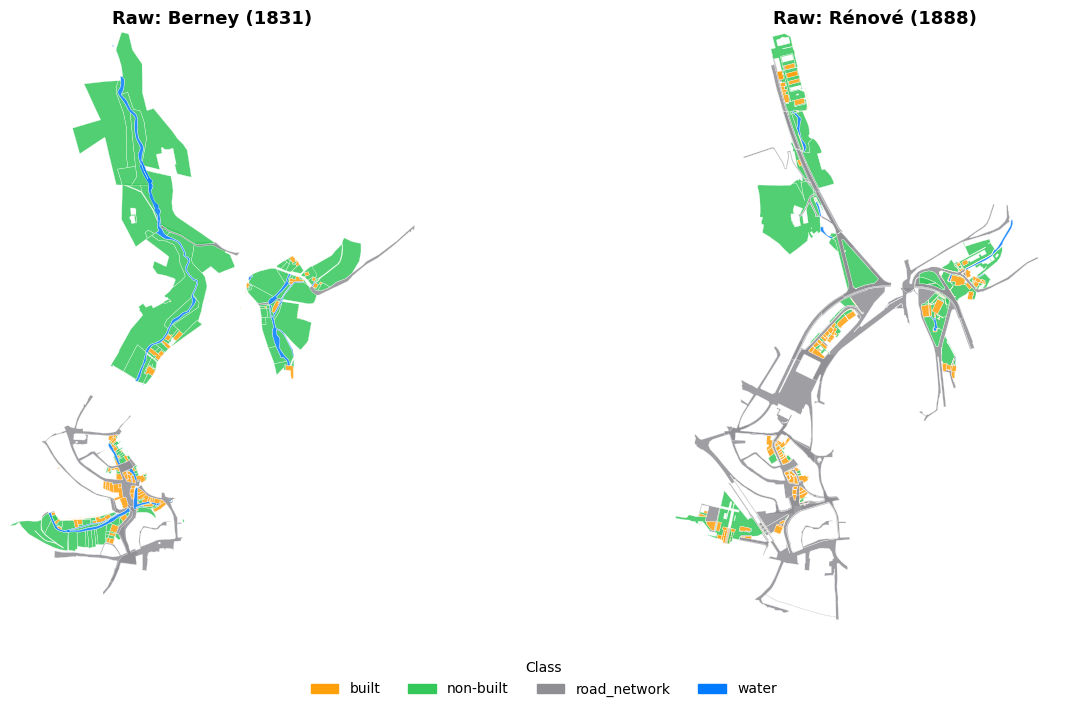

Saved: ../../stat_analysis/output/comp_analysis_refactored/berneyrenove/raw/figures/category_graph_raw.png


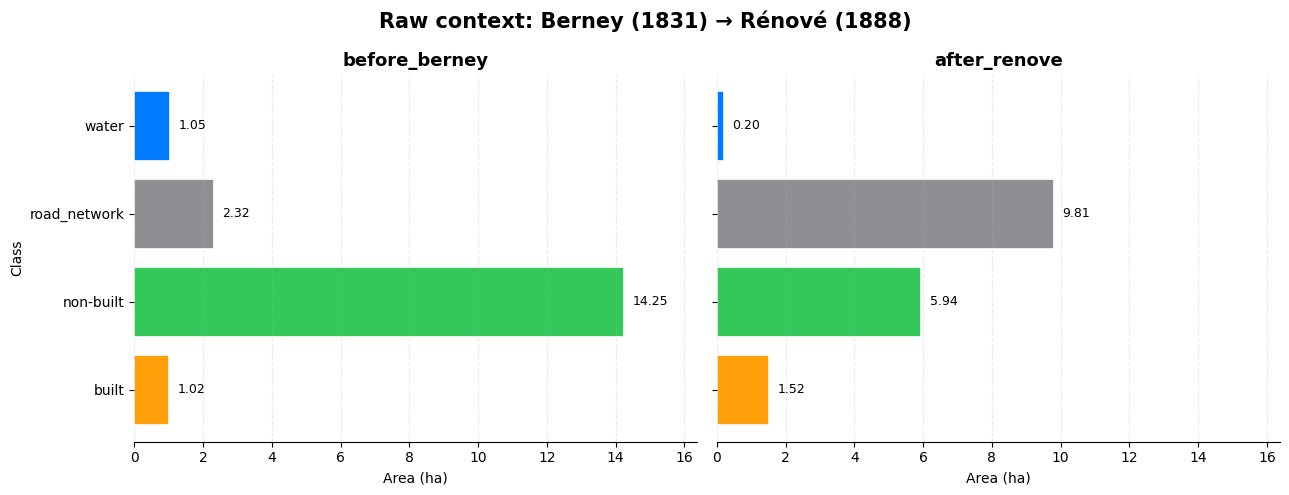

Shared area check


,scope,area_ha
0,raw_before,18.635368
1,raw_after,17.481837
2,shared_footprint,9.762886
3,before_clipped_to_shared,10.201004
4,after_clipped_to_shared,11.615648


Shared category summary


,class,feature_count,total_area_m2,total_area_ha,map
0,non-built,162,69797.481398,6.979748,before_berney_shared
1,road_network,17,16298.828158,1.629883,before_berney_shared
2,water,28,9652.095175,0.965210,before_berney_shared
3,built,118,6261.635485,0.626164,before_berney_shared
4,road_network,121,59214.283607,5.921428,after_renove_shared
5,non-built,169,42297.515987,4.229752,after_renove_shared
6,built,321,13387.665541,1.338767,after_renove_shared
7,water,23,1257.013526,0.125701,after_renove_shared


Shared total area


,map,total_area_ha,shared_footprint_area_ha,coverage_difference_from_shared_ha
0,after_renove_shared,11.615648,9.762886,1.852761
1,before_berney_shared,10.201004,9.762886,0.438118


Saved: ../../stat_analysis/output/comp_analysis_refactored/berneyrenove/shared_intersection/tables/area_check_shared.csv
Saved: ../../stat_analysis/output/comp_analysis_refactored/berneyrenove/shared_intersection/tables/category_summary_shared.csv
Saved: ../../stat_analysis/output/comp_analysis_refactored/berneyrenove/shared_intersection/tables/total_area_shared.csv
Saved: ../../stat_analysis/output/comp_analysis_refactored/berneyrenove/shared_intersection/figures/before_after_maps_shared.png


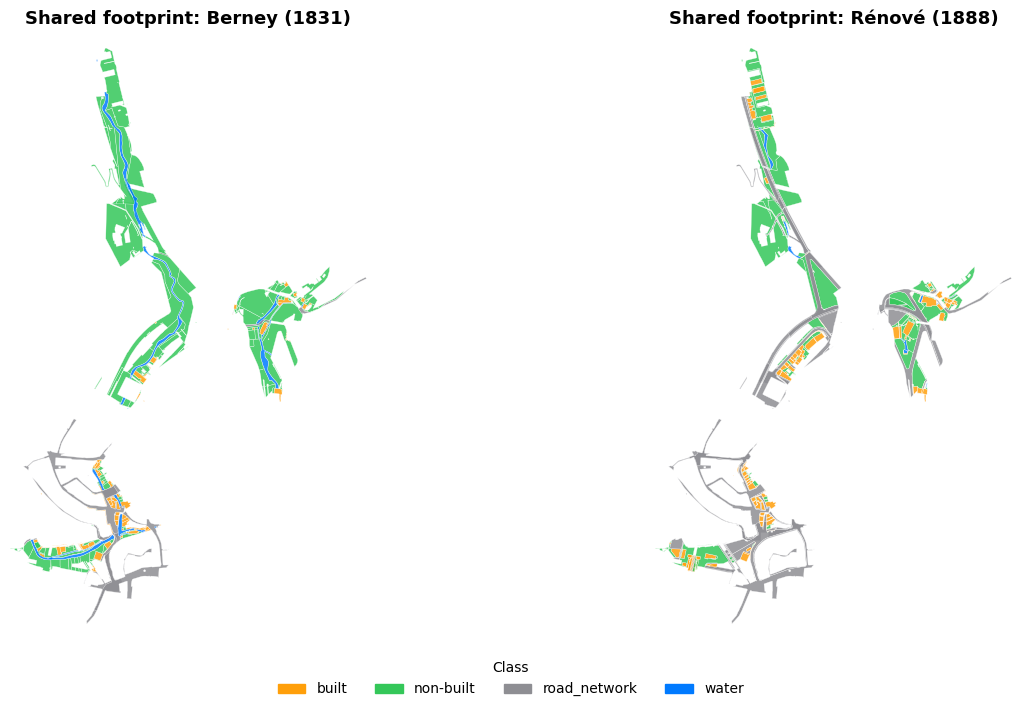

Saved: ../../stat_analysis/output/comp_analysis_refactored/berneyrenove/shared_intersection/figures/category_graph_shared.png


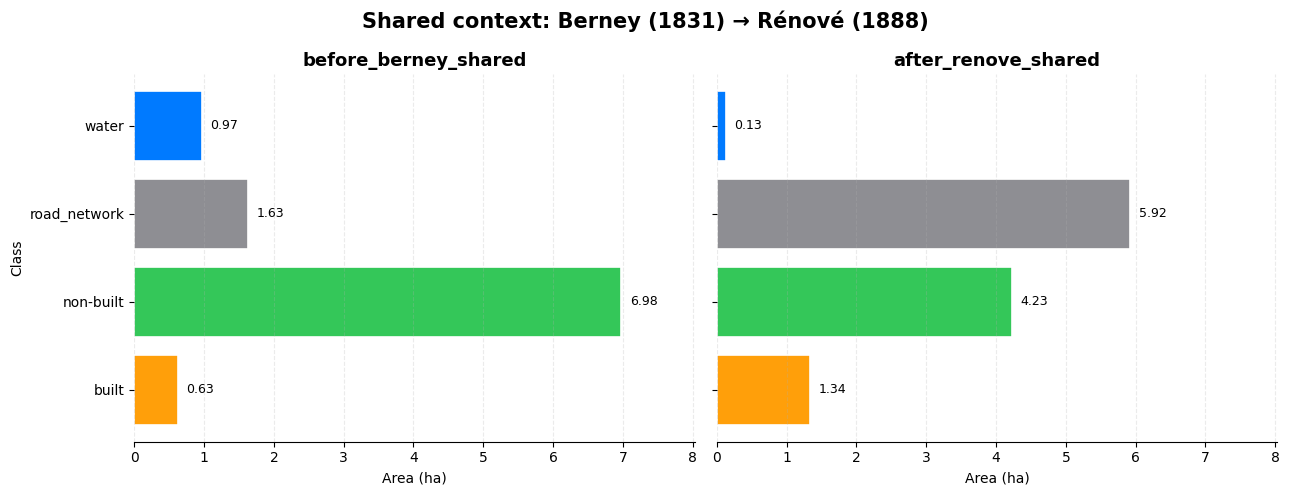

Changed-only summary


,change_group,change_type,feature_count,total_area_m2,total_area_ha
7,became road,non-built → road_network,357,36280.283857,3.628028
0,became built,non-built → built,406,8219.725387,0.821973
8,became road,water → road_network,129,6981.397327,0.698140
5,became non-built,water → non-built,91,3278.276991,0.327828
6,became road,built → road_network,180,2571.662650,0.257166
2,became built,water → built,161,1634.924806,0.163492
3,became non-built,built → non-built,57,832.122895,0.083212
1,became built,road_network → built,59,327.918950,0.032792
10,became water,non-built → water,32,313.824431,0.031382
4,became non-built,road_network → non-built,21,297.858004,0.029786


Saved: ../../stat_analysis/output/comp_analysis_refactored/berneyrenove/shared_intersection/tables/change_summary_shared.csv
Saved: ../../stat_analysis/output/comp_analysis_refactored/berneyrenove/shared_intersection/figures/changed_only_map_shared.png


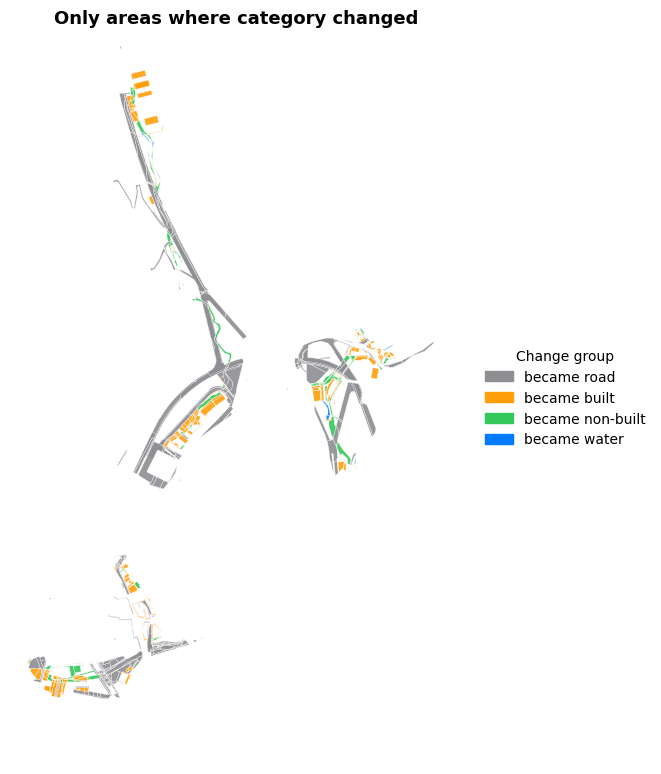


melotteberney: Melotte (1721) → Berney (1831) | simple_pair
Raw category summary


,class,feature_count,total_area_m2,total_area_ha,map
0,non-built,169,312163.992281,31.216399,before_melotte
1,road_network,43,16251.816721,1.625182,before_melotte
2,built,130,15123.063995,1.512306,before_melotte
3,water,12,4413.496342,0.441350,before_melotte
4,non-built,227,319774.217409,31.977422,after_berney
5,road_network,35,24667.539417,2.466754,after_berney
6,built,188,18853.196747,1.885320,after_berney


Raw total area


,map,total_area_ha
0,after_berney,36.329495
1,before_melotte,34.795237


Saved: ../../stat_analysis/output/comp_analysis_refactored/melotteberney/raw/tables/category_summary_raw.csv
Saved: ../../stat_analysis/output/comp_analysis_refactored/melotteberney/raw/tables/total_area_raw.csv
Saved: ../../stat_analysis/output/comp_analysis_refactored/melotteberney/raw/figures/before_after_maps_raw.png


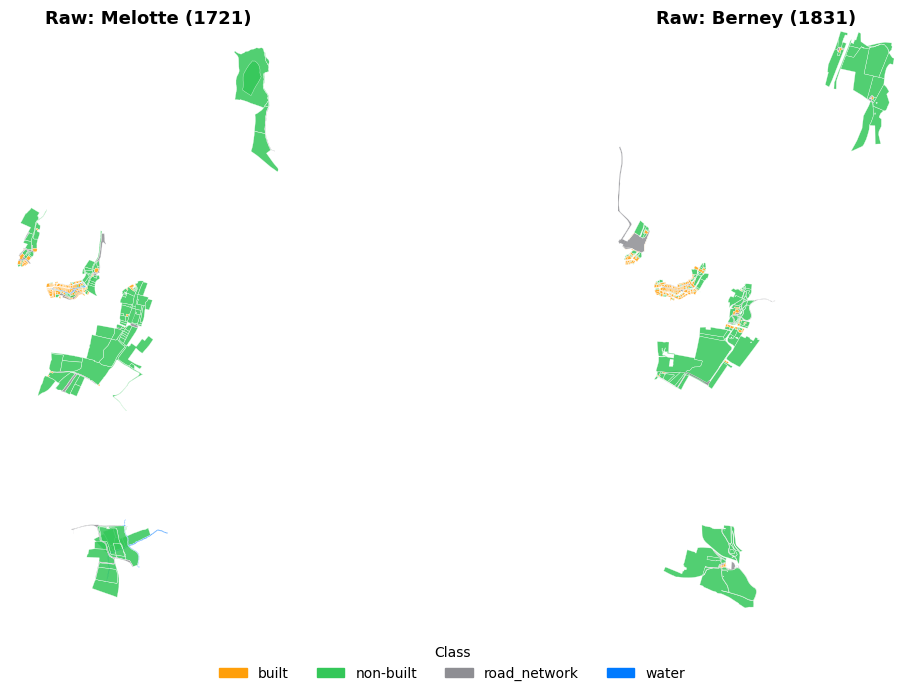

Saved: ../../stat_analysis/output/comp_analysis_refactored/melotteberney/raw/figures/category_graph_raw.png


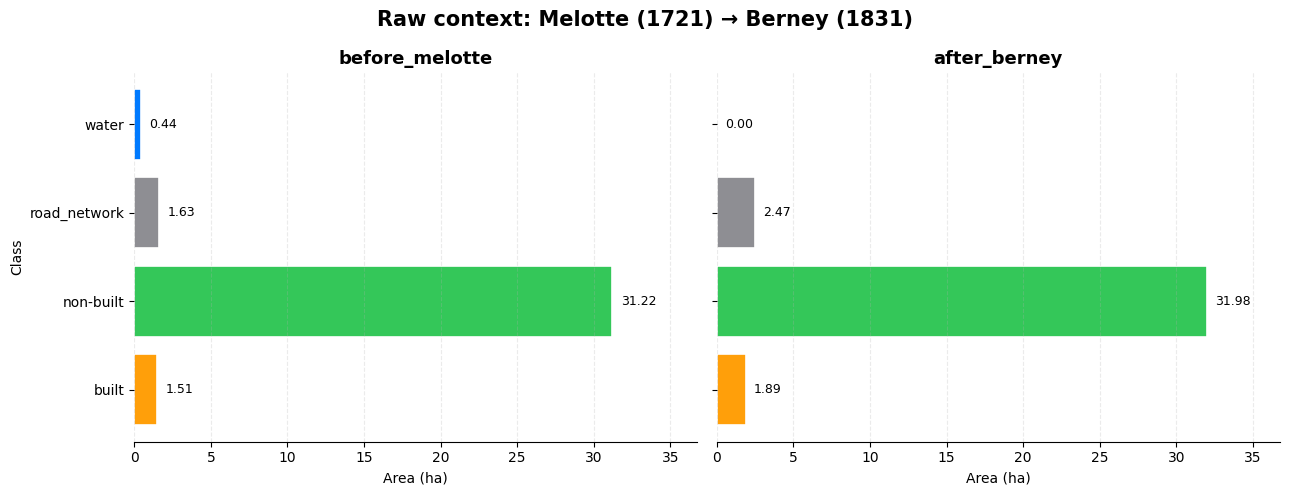

Shared area check


,scope,area_ha
0,raw_before,34.795237
1,raw_after,36.329495
2,shared_footprint,22.671354
3,before_clipped_to_shared,25.611398
4,after_clipped_to_shared,22.889403


Shared category summary


,class,feature_count,total_area_m2,total_area_ha,map
0,non-built,169,233008.359398,23.300836,before_melotte_shared
1,built,130,11374.178279,1.137418,before_melotte_shared
2,road_network,43,9113.760867,0.911376,before_melotte_shared
3,water,12,2617.680364,0.261768,before_melotte_shared
4,non-built,200,199727.142777,19.972714,after_berney_shared
5,built,184,15177.273595,1.517727,after_berney_shared
6,road_network,30,13989.615400,1.398962,after_berney_shared


Shared total area


,map,total_area_ha,shared_footprint_area_ha,coverage_difference_from_shared_ha
0,after_berney_shared,22.889403,22.671354,0.218049
1,before_melotte_shared,25.611398,22.671354,2.940044


Saved: ../../stat_analysis/output/comp_analysis_refactored/melotteberney/shared_intersection/tables/area_check_shared.csv
Saved: ../../stat_analysis/output/comp_analysis_refactored/melotteberney/shared_intersection/tables/category_summary_shared.csv
Saved: ../../stat_analysis/output/comp_analysis_refactored/melotteberney/shared_intersection/tables/total_area_shared.csv
Saved: ../../stat_analysis/output/comp_analysis_refactored/melotteberney/shared_intersection/figures/before_after_maps_shared.png


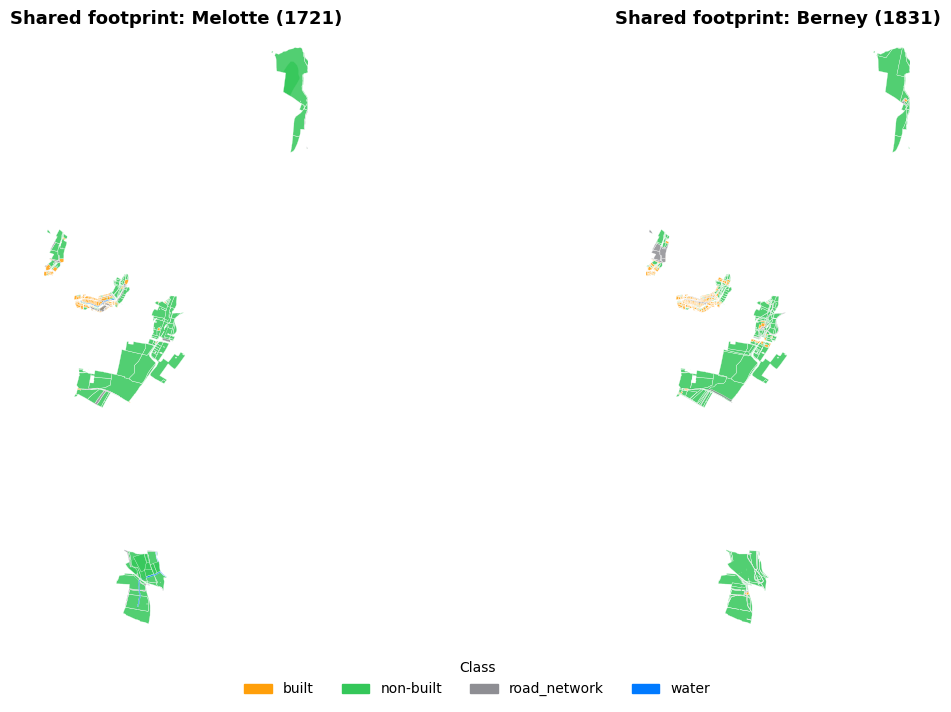

Saved: ../../stat_analysis/output/comp_analysis_refactored/melotteberney/shared_intersection/figures/category_graph_shared.png


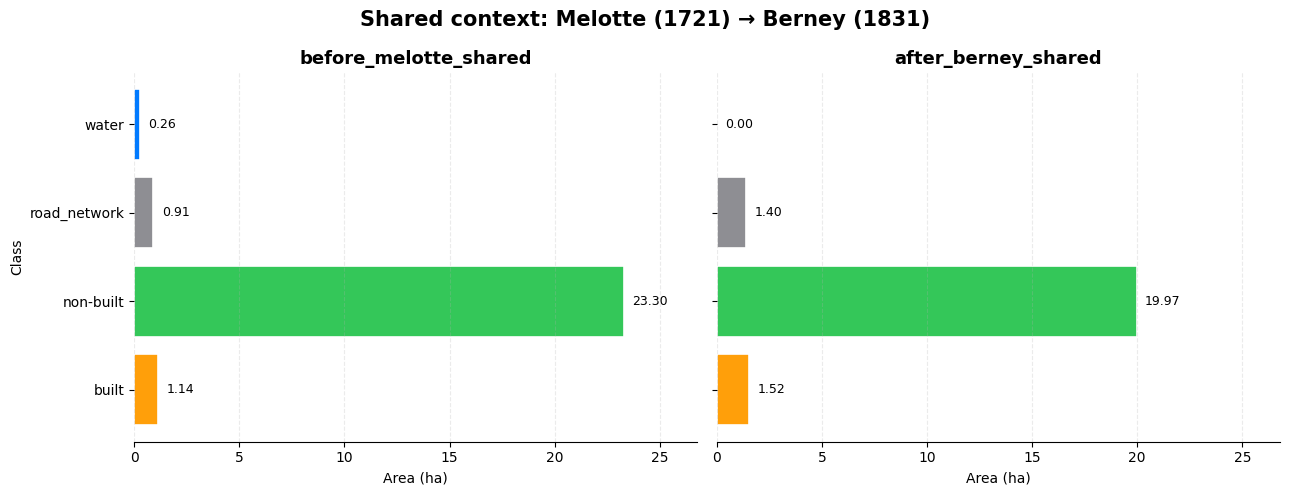

Changed-only summary


,change_group,change_type,feature_count,total_area_m2,total_area_ha
7,became road,non-built → road_network,85,12027.398539,1.202740
0,became built,non-built → built,181,5586.570369,0.558657
4,became non-built,road_network → non-built,90,5080.296784,0.508030
1,became built,road_network → built,93,2873.251187,0.287325
5,became non-built,water → non-built,24,1849.859074,0.184986
6,became road,built → road_network,63,1639.743440,0.163974
3,became non-built,built → non-built,95,1363.964434,0.136396
2,became built,water → built,42,625.394003,0.062539
8,became road,water → road_network,10,157.091591,0.015709


Saved: ../../stat_analysis/output/comp_analysis_refactored/melotteberney/shared_intersection/tables/change_summary_shared.csv
Saved: ../../stat_analysis/output/comp_analysis_refactored/melotteberney/shared_intersection/figures/changed_only_map_shared.png


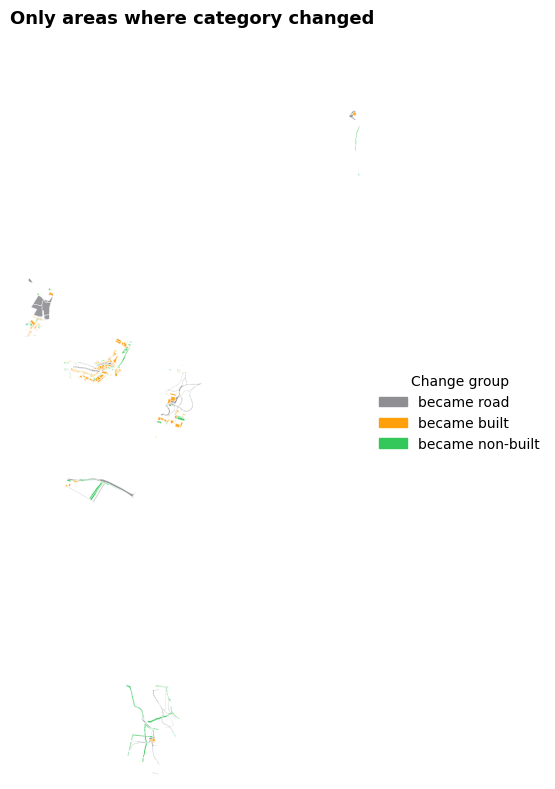


renovecontemporain: Rénové (1888) → Contemporary (2021) | merged_contemporain
Raw category summary


,class,feature_count,total_area_m2,total_area_ha,map
0,non-built,725,1.113192e+06,111.319232,before_renove
1,road_network,308,1.638356e+05,16.383556,before_renove
2,water,198,5.982706e+04,5.982706,before_renove
3,built,1177,4.857377e+04,4.857377,before_renove
4,non-built,29,6.058035e+05,60.580348,after_contemporain
5,road_network,405,4.902788e+05,49.027881,after_contemporain
6,built,255,1.738886e+05,17.388856,after_contemporain
7,water,2,1.525279e+02,0.015253,after_contemporain


Raw total area


,map,total_area_ha
0,after_contemporain,127.012338
1,before_renove,138.542871


Saved: ../../stat_analysis/output/comp_analysis_refactored/renovecontemporain/raw/tables/category_summary_raw.csv
Saved: ../../stat_analysis/output/comp_analysis_refactored/renovecontemporain/raw/tables/total_area_raw.csv
Saved: ../../stat_analysis/output/comp_analysis_refactored/renovecontemporain/raw/figures/before_after_maps_raw.png


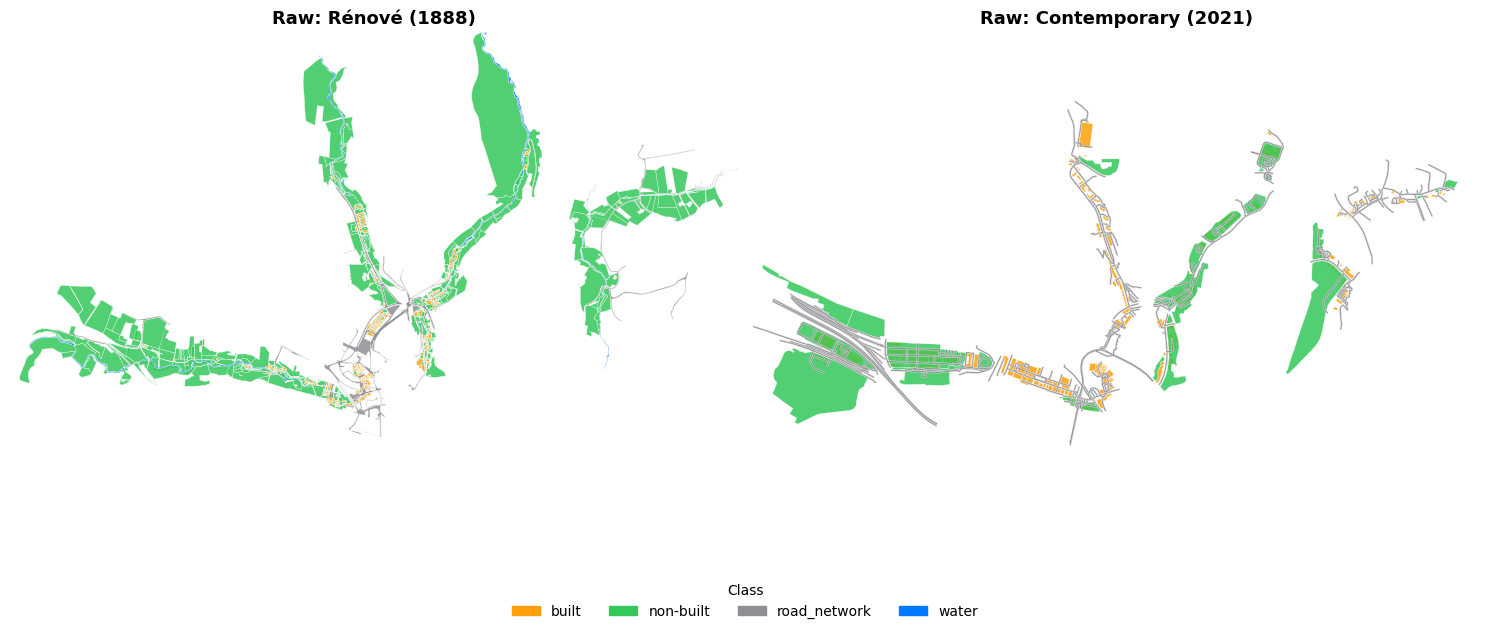

Saved: ../../stat_analysis/output/comp_analysis_refactored/renovecontemporain/raw/figures/category_graph_raw.png


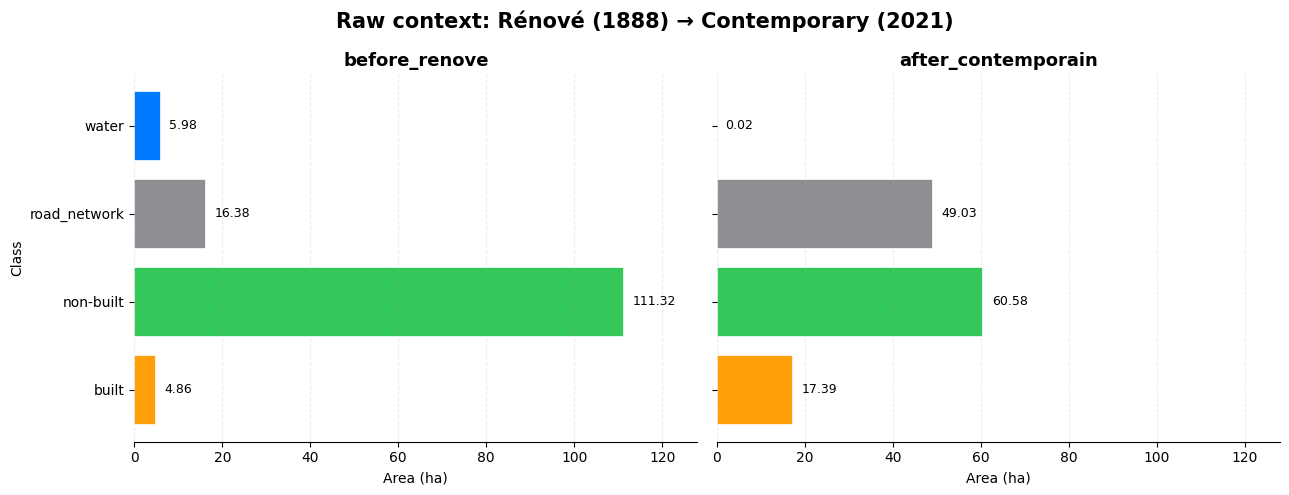

Shared area check


,scope,area_ha
0,raw_before,138.542871
1,raw_after,127.012338
2,shared_footprint,56.869194
3,before_clipped_to_shared,62.765458
4,after_clipped_to_shared,81.494362


Shared category summary


,class,feature_count,total_area_m2,total_area_ha,map
0,non-built,683,476406.291890,47.640629,before_renove_shared
1,road_network,300,76197.318691,7.619732,before_renove_shared
2,built,1077,38580.163037,3.858016,before_renove_shared
3,water,186,36470.809880,3.647081,before_renove_shared
4,road_network,405,362385.763200,36.238576,after_contemporain_shared
5,non-built,29,296078.500360,29.607850,after_contemporain_shared
6,built,255,156326.825162,15.632683,after_contemporain_shared
7,water,2,152.527852,0.015253,after_contemporain_shared


Shared total area


,map,total_area_ha,shared_footprint_area_ha,coverage_difference_from_shared_ha
0,after_contemporain_shared,81.494362,56.869194,24.625167
1,before_renove_shared,62.765458,56.869194,5.896264


Saved: ../../stat_analysis/output/comp_analysis_refactored/renovecontemporain/shared_intersection/tables/area_check_shared.csv
Saved: ../../stat_analysis/output/comp_analysis_refactored/renovecontemporain/shared_intersection/tables/category_summary_shared.csv
Saved: ../../stat_analysis/output/comp_analysis_refactored/renovecontemporain/shared_intersection/tables/total_area_shared.csv
Saved: ../../stat_analysis/output/comp_analysis_refactored/renovecontemporain/shared_intersection/figures/before_after_maps_shared.png


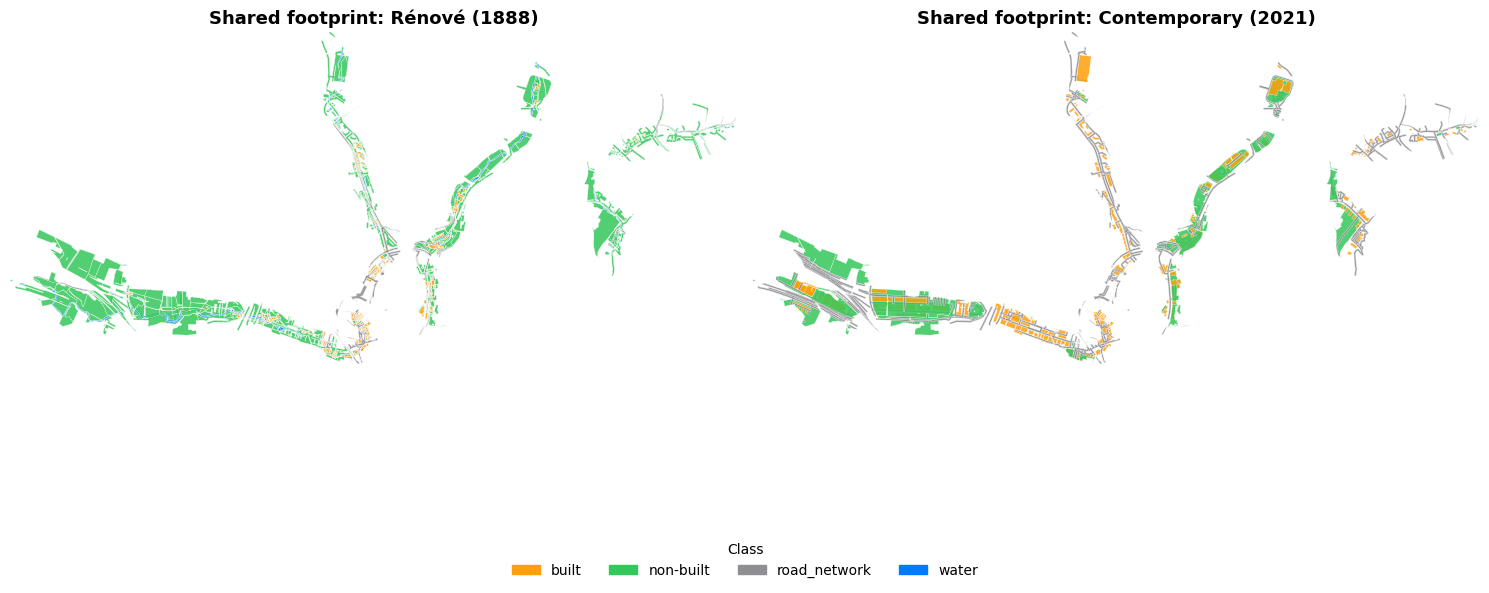

Saved: ../../stat_analysis/output/comp_analysis_refactored/renovecontemporain/shared_intersection/figures/category_graph_shared.png


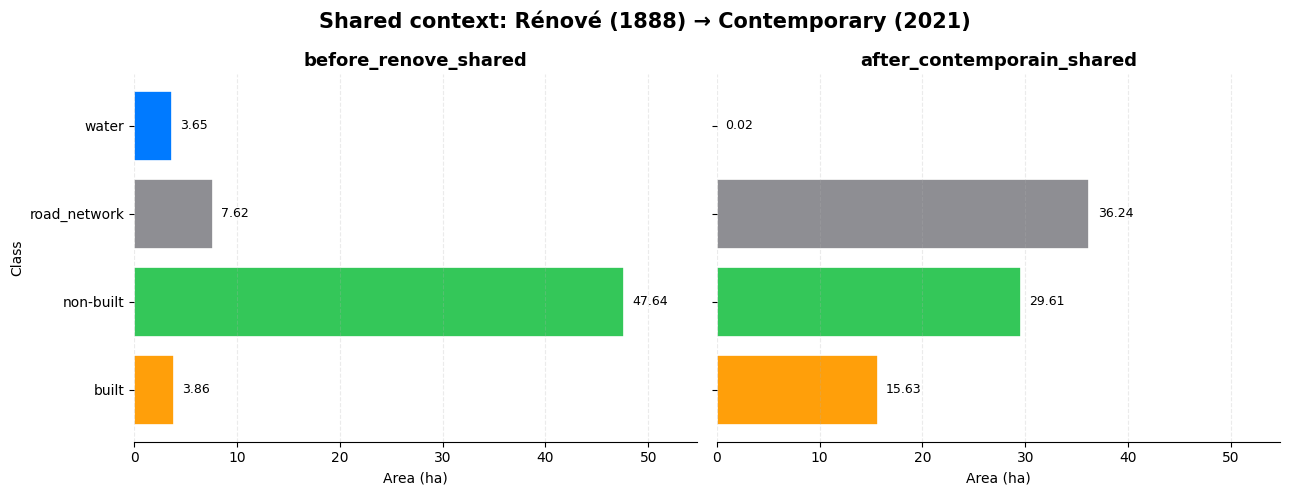

Changed-only summary


,change_group,change_type,feature_count,total_area_m2,total_area_ha
7,became road,non-built → road_network,1607,283039.315184,28.303932
0,became built,non-built → built,691,128856.660013,12.885666
8,became road,water → road_network,463,22517.987617,2.251799
6,became road,built → road_network,1354,21861.740481,2.186174
5,became non-built,water → non-built,127,20010.646087,2.001065
3,became non-built,built → non-built,439,15812.325552,1.581233
4,became non-built,road_network → non-built,86,12259.562648,1.225956
2,became built,water → built,211,12254.336115,1.225434
1,became built,road_network → built,212,8092.857553,0.809286
9,became water,non-built → water,4,149.327471,0.014933


Saved: ../../stat_analysis/output/comp_analysis_refactored/renovecontemporain/shared_intersection/tables/change_summary_shared.csv
Saved: ../../stat_analysis/output/comp_analysis_refactored/renovecontemporain/shared_intersection/figures/changed_only_map_shared.png


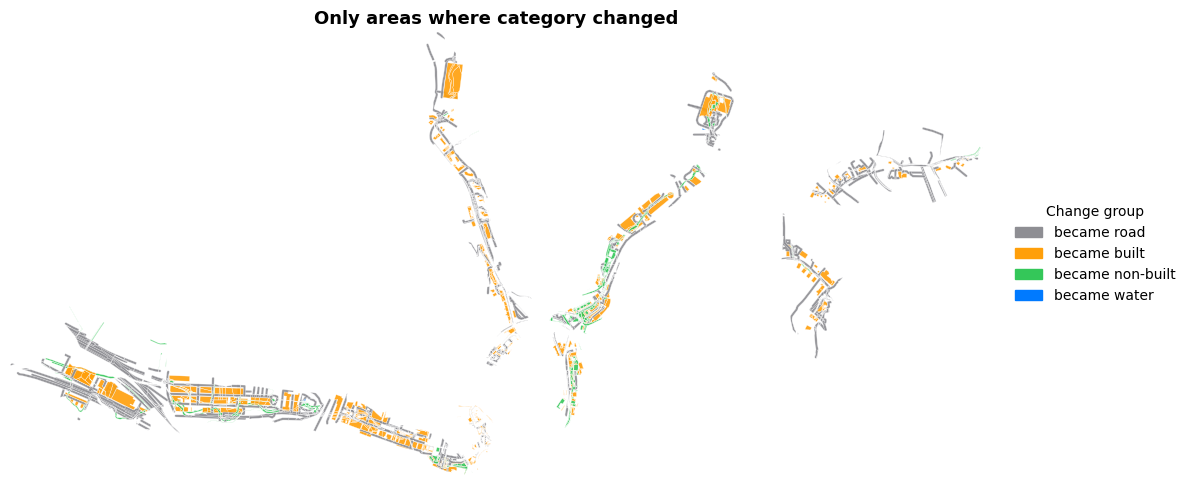

,comparison_key,before_map,after_map,mode,raw_before_area_ha,raw_after_area_ha,shared_footprint_area_ha
0,berneyrenove,berney,renove,simple_pair,18.635368,17.481837,9.762886
1,melotteberney,melotte,berney,simple_pair,34.795237,36.329495,22.671354
2,renovecontemporain,renove,contemporain,merged_contemporain,138.542871,127.012338,56.869194


In [26]:
run_results = []

for spec in pair_specs:
    try:
        run_results.append(run_pair_analysis(spec))
    except Exception as exc:
        print("FAILED:", spec)
        print(exc)

run_results_df = pd.DataFrame(run_results)
display(run_results_df)

## 7. To save outputs

Set this at the top:

```python
SAVE_OUTPUTS = True
```

Each comparison will be saved into its own folder:

```text
stat_analysis/output/comp_analysis_refactored/<comparison_key>/
├── raw/
│   ├── tables/
│   └── figures/
└── shared_intersection/
    ├── tables/
    └── figures/
```